# Multi Class Chest Radiography with DenseNet121 and Grad-CAM. Full Pipeline in One Notebook

**Project:** Multimodal Explainable AI for Chest Radiology, Master 2 ISI
**Scope:** preprocessing, DenseNet121 training, full multi class evaluation and Grad-CAM explanation in a single reproducible file, identical in every step to the ResNet50 COVID notebook of the project except for the backbone. Together the two notebooks give a controlled two backbone comparison on the four class problem.

**Backbone: DenseNet121 pretrained on ImageNet,** the CheXNet standard of chest radiography, winner of the four backbone study of the project on Kermany, classifier of the Nature Machine Intelligence 2022 reference pipeline, and one of the ensemble members of the Ensemble-CAM 2024 paper that uses this very dataset.

**Dataset: COVID-19 Radiography Database,** in the SOTA table via Ensemble-CAM 2024. Four classes, Normal, Lung Opacity, COVID, Viral Pneumonia, 21,165 images.

**Kaggle setup.** Add Input, Datasets, `COVID-19 Radiography Database` by Tawsifur Rahman, GPU T4, Internet On.

**Outputs saved in `/kaggle/working`:** frozen splits, `densenet121_covid_best.pth`, metrics json, per image predictions, evaluation figures and the two Grad-CAM figures.


## Part 1. Setup and reproducibility

Seed 42 on every generator. Same seed and same split code as the ResNet50 COVID notebook, so both backbones are trained and tested on exactly the same images.

In [1]:
import os
import glob
import json
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = "/kaggle/working"
print("Device:", DEVICE)

Device: cpu


## Part 2. Preprocessing step one, locate the data and build the index

The root is resolved by searching for the COVID class folder. One row per image with path, class name and integer target.

In [2]:
covid_dirs = glob.glob("/kaggle/input/**/COVID/images", recursive=True)
DATA_ROOT = os.path.dirname(os.path.dirname(covid_dirs[0]))
print("Data root:", DATA_ROOT)

CLASSES = ["Normal", "Lung_Opacity", "COVID", "Viral Pneumonia"]
class_to_target = {c: i for i, c in enumerate(CLASSES)}

rows = []
for cls in CLASSES:
    folder = os.path.join(DATA_ROOT, cls, "images")
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith(".png"):
            rows.append({"filepath": os.path.join(folder, fname),
                         "filename": fname,
                         "class": cls,
                         "target": class_to_target[cls]})

table = pd.DataFrame(rows)
print(table["class"].value_counts())
print("Total images:", len(table))

Data root: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset
class
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345
Name: count, dtype: int64
Total images: 21165


## Part 3. Preprocessing step two, stratified split and its stated limitation

This dataset publishes no patient identifier, so the split is stratified at image level with the 70 10 20 proportions of Scientific Reports 2025 and MedVAG, the same known threat to validity acknowledged by PLOS ONE 2024 and stated as such in the thesis, RSNA providing the leak free counterpart of the project.

In [3]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(table, test_size=0.30,
                                     stratify=table["target"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=2/3,
                                   stratify=temp_df["target"], random_state=SEED)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, len(d))

cols = ["filepath", "filename", "class", "target"]
train_df[cols].to_csv(os.path.join(OUTPUT_DIR, "covid_train.csv"), index=False)
val_df[cols].to_csv(os.path.join(OUTPUT_DIR, "covid_val.csv"), index=False)
test_df[cols].to_csv(os.path.join(OUTPUT_DIR, "covid_test.csv"), index=False)
print("Splits frozen on disk")

train 14815
val 2116
test 4234
Splits frozen on disk


## Part 4. Preprocessing step three, transformations and loaders

Resize 224, ImageNet normalization, and the MDPI Information 2025 augmentation parameters on the training set only, identical to every classification notebook of the project.

In [4]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(15),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class CovidDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        return self.transform(img), torch.tensor(row["target"], dtype=torch.long)

BATCH_SIZE = 32
train_loader = DataLoader(CovidDataset(train_df, train_transform), batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(CovidDataset(val_df, eval_transform), batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(CovidDataset(test_df, eval_transform), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)
print("Batches per training epoch:", len(train_loader))

Batches per training epoch: 463


## Part 5. Model, DenseNet121 with a four class head

The only architectural change against the ResNet50 COVID notebook. DenseNet121 with ImageNet weights, classifier replaced by a four class layer. Loss, class weighting, optimizer and scheduler stay identical and keep their SOTA justifications, weighted categorical cross entropy from Ensemble-CAM with inverse frequency weights motivated by Scientific Reports 2025, Adam 1e-4 from Nature Machine Intelligence 2022, ReduceLROnPlateau from PLOS ONE 2024.

In [5]:
NUM_CLASSES = 4
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
model = model.to(DEVICE)

counts = train_df["target"].value_counts().sort_index().values
class_weights = torch.tensor(len(train_df) / (NUM_CLASSES * counts),
                             dtype=torch.float32).to(DEVICE)
print("Class weights:", dict(zip(CLASSES, class_weights.cpu().numpy().round(3))))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                       factor=0.1, patience=2)
print("Trainable parameters in millions:",
      round(sum(p.numel() for p in model.parameters()) / 1e6, 1))

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 152MB/s]


Class weights: {'Normal': np.float32(0.519), 'Lung_Opacity': np.float32(0.88), 'COVID': np.float32(1.463), 'Viral Pneumonia': np.float32(3.932)}
Trainable parameters in millions: 7.0


## Part 6. Training with early stopping on the macro F1

Model selection on the macro F1 as in the Scientific Reports 2025 paper, because plain accuracy would be dominated by the Normal class. Cap of ten epochs with patience three, same budget logic as every training notebook of the project.

In [6]:
from sklearn.metrics import f1_score

def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []
    with torch.set_grad_enabled(train_mode):
        for images, targets in loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, targets)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(targets)
            all_labels.extend(targets.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, dim=1).detach().cpu().numpy())
    return (total_loss / len(loader.dataset),
            np.array(all_labels), np.array(all_probs))

EPOCHS = 10
PATIENCE = 3
CKPT = os.path.join(OUTPUT_DIR, "densenet121_covid_best.pth")
best_f1, without_improvement = 0.0, 0
history = []

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss, _, _ = run_epoch(train_loader, True)
    val_loss, val_labels, val_probs = run_epoch(val_loader, False)
    val_preds = val_probs.argmax(axis=1)
    val_f1 = f1_score(val_labels, val_preds, average="macro")
    scheduler.step(val_f1)
    history.append({"epoch": epoch, "train_loss": train_loss,
                    "val_loss": val_loss, "val_macro_f1": val_f1})
    print(f"epoch {epoch}  train_loss {train_loss:.4f}  val_loss {val_loss:.4f}"
          f"  val_macro_f1 {val_f1:.4f}  minutes {round((time.time() - start) / 60, 1)}")
    if val_f1 > best_f1:
        best_f1, without_improvement = val_f1, 0
        torch.save(model.state_dict(), CKPT)
        print("new best model saved")
    else:
        without_improvement += 1
        if without_improvement >= PATIENCE:
            print("early stopping")
            break

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 1  train_loss 0.3621  val_loss 0.2156  val_macro_f1 0.9089  minutes 78.4
new best model saved


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 2  train_loss 0.2101  val_loss 0.1794  val_macro_f1 0.9117  minutes 83.2
new best model saved


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

epoch 6  train_loss 0.1196  val_loss 0.1891  val_macro_f1 0.9353  minutes 83.7


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 7  train_loss 0.1150  val_loss 0.1758  val_macro_f1 0.9435  minutes 85.4


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 8  train_loss 0.1020  val_loss 0.1486  val_macro_f1 0.9390  minutes 84.9
early stopping


## Part 7. Multi class evaluation on the held out test set

Same protocol as the ResNet50 COVID notebook. Overall accuracy, macro precision, recall and F1, one versus rest macro AUC, per class classification report and confusion matrix. The direct comparison point is the ResNet50 run of the project on the exact same split, accuracy 0.9313, macro F1 0.9297, macro AUC 0.9913.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


accuracy: 0.9521
macro_precision: 0.9660
macro_recall: 0.9421
macro_f1: 0.9534
macro_auc_ovr: 0.9945

                 precision    recall  f1-score   support

         Normal     0.9342    0.9750    0.9542      2039
   Lung_Opacity     0.9572    0.9102    0.9331      1203
          COVID     0.9846    0.9723    0.9784       723
Viral Pneumonia     0.9879    0.9108    0.9478       269

       accuracy                         0.9521      4234
      macro avg     0.9660    0.9421    0.9534      4234
   weighted avg     0.9527    0.9521    0.9519      4234



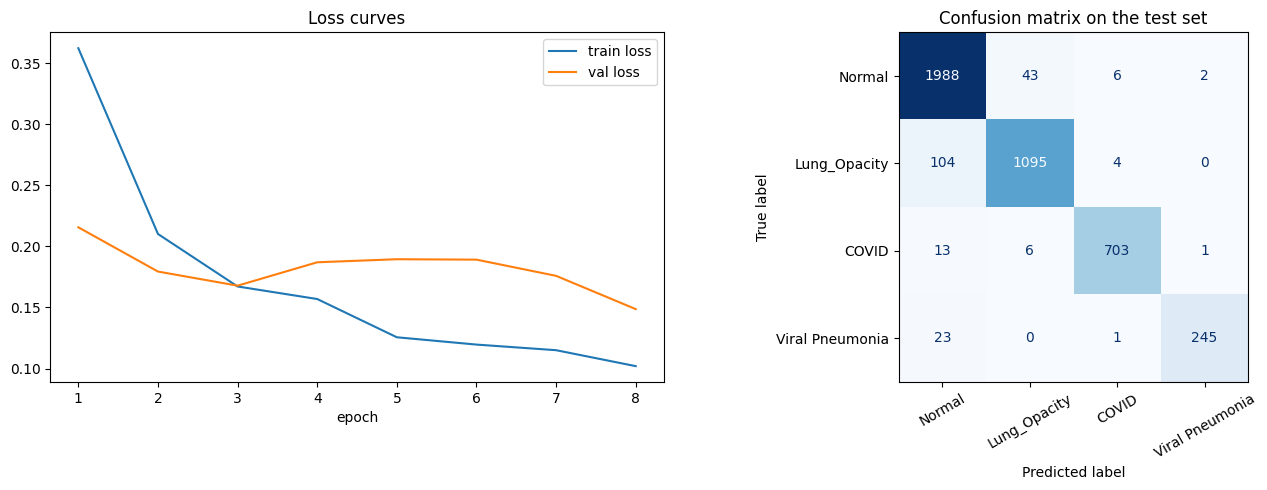

In [7]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

model.load_state_dict(torch.load(CKPT))
_, test_labels, test_probs = run_epoch(test_loader, False)
test_preds = test_probs.argmax(axis=1)

metrics = {
    "accuracy": accuracy_score(test_labels, test_preds),
    "macro_precision": precision_score(test_labels, test_preds, average="macro"),
    "macro_recall": recall_score(test_labels, test_preds, average="macro"),
    "macro_f1": f1_score(test_labels, test_preds, average="macro"),
    "macro_auc_ovr": roc_auc_score(test_labels, test_probs,
                                   multi_class="ovr", average="macro")
}
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print()
print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=4))

with open(os.path.join(OUTPUT_DIR, "densenet121_covid_metrics.json"), "w") as f:
    json.dump({k: round(v, 4) for k, v in metrics.items()}, f, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hist = pd.DataFrame(history)
axes[0].plot(hist["epoch"], hist["train_loss"], label="train loss")
axes[0].plot(hist["epoch"], hist["val_loss"], label="val loss")
axes[0].legend()
axes[0].set_xlabel("epoch")
axes[0].set_title("Loss curves")

cm = confusion_matrix(test_labels, test_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap="Blues", ax=axes[1],
                                                        colorbar=False, xticks_rotation=30)
axes[1].set_title("Confusion matrix on the test set")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "densenet121_covid_evaluation.png"), dpi=200,
            bbox_inches="tight")
plt.show()

out = test_df[["filename", "class", "target"]].copy()
for i, cls in enumerate(CLASSES):
    out[f"prob_{cls}"] = test_probs[:, i]
out["prediction"] = test_preds
out.to_csv(os.path.join(OUTPUT_DIR, "densenet121_covid_test_predictions.csv"), index=False)

## Part 8. Grad-CAM explanation per class

Grad-CAM following its original paper, Selvaraju et al. ICCV 2017. The target layer for DenseNet121 is the last dense block of the feature extractor, features minus one, the standard choice for this architecture and the one used by the Nature Machine Intelligence 2022 reference pipeline, Grad-CAM plus DenseNet121. One correctly classified example per class is explained.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


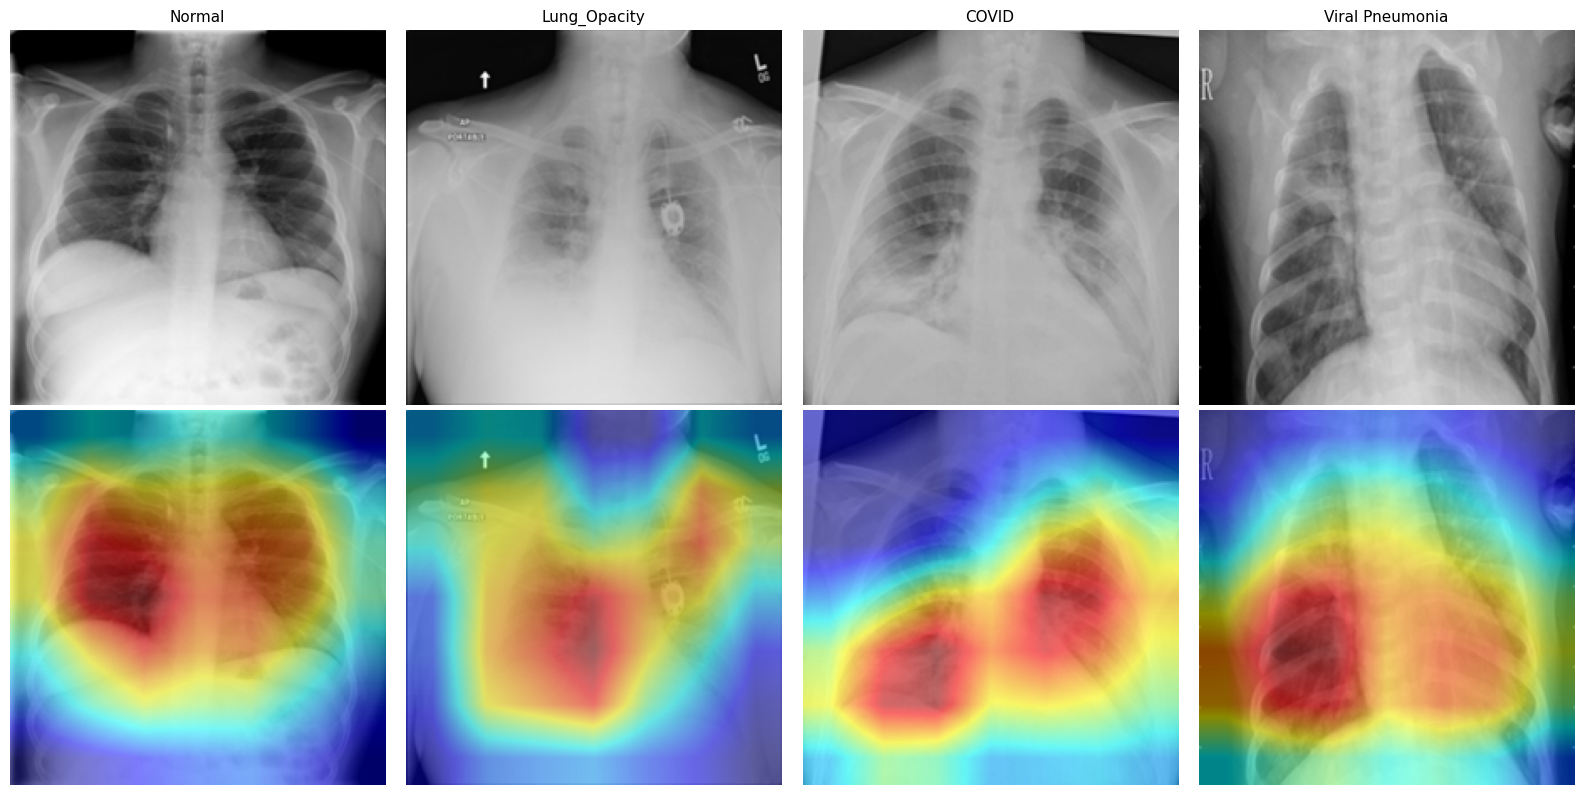

In [8]:
!pip install grad-cam --quiet
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

model.eval()
cam = GradCAM(model=model, target_layers=[model.features[-1]])

def load_for_cam(filepath):
    img = Image.open(filepath).convert("RGB")
    tensor = eval_transform(img).unsqueeze(0).to(DEVICE)
    display = np.array(img.resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32) / 255.0
    return tensor, display

test_eval = test_df.reset_index(drop=True).copy()
test_eval["prediction"] = test_preds

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for c, cls in enumerate(CLASSES):
    pool = test_eval[(test_eval["class"] == cls) &
                     (test_eval["prediction"] == class_to_target[cls])]
    row = pool.sample(1, random_state=SEED).iloc[0]
    tensor, display = load_for_cam(row["filepath"])
    heatmap = cam(input_tensor=tensor,
                  targets=[ClassifierOutputTarget(class_to_target[cls])])[0]
    axes[0, c].imshow(display)
    axes[0, c].set_title(cls, fontsize=11)
    axes[0, c].axis("off")
    axes[1, c].imshow(show_cam_on_image(display, heatmap, use_rgb=True))
    axes[1, c].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "densenet121_gradcam_per_class.png"), dpi=200,
            bbox_inches="tight")
plt.show()

## Part 9. Class discriminative heatmaps of one image

The same COVID image explained against the four class scores, demonstrating the class discriminative property of Grad-CAM on this backbone. Comparing this figure with its ResNet50 counterpart shows whether the extra anatomical activations observed on low scoring classes with ResNet50 persist with DenseNet121, which informs the shortcut learning discussion of the thesis.

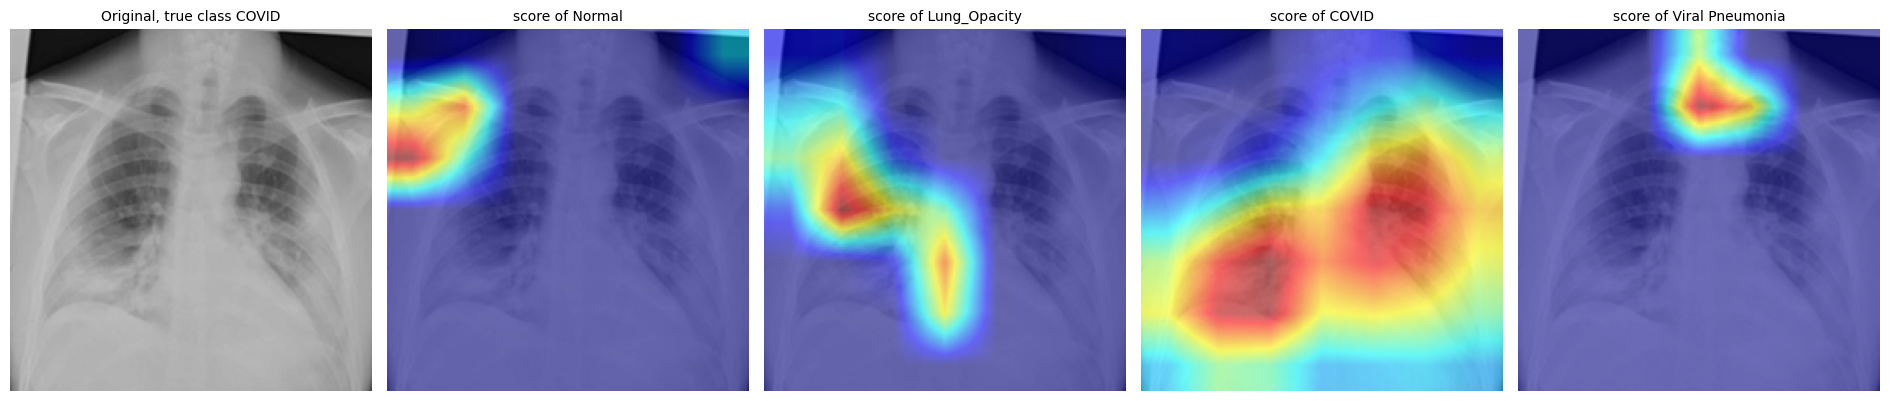

Final content of the working directory:
  __notebook__.ipynb
  covid_test.csv
  covid_train.csv
  covid_val.csv
  densenet121_covid_best.pth
  densenet121_covid_evaluation.png
  densenet121_covid_metrics.json
  densenet121_covid_test_predictions.csv
  densenet121_gradcam_class_discriminative.png
  densenet121_gradcam_per_class.png


In [9]:
row = test_eval[(test_eval["class"] == "COVID") &
                (test_eval["prediction"] == class_to_target["COVID"])].sample(
                1, random_state=SEED).iloc[0]
tensor, display = load_for_cam(row["filepath"])

fig, axes = plt.subplots(1, 5, figsize=(19, 4))
axes[0].imshow(display)
axes[0].set_title("Original, true class COVID", fontsize=10)
axes[0].axis("off")
for c, cls in enumerate(CLASSES):
    heatmap = cam(input_tensor=tensor,
                  targets=[ClassifierOutputTarget(class_to_target[cls])])[0]
    axes[c + 1].imshow(show_cam_on_image(display, heatmap, use_rgb=True))
    axes[c + 1].set_title(f"score of {cls}", fontsize=10)
    axes[c + 1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "densenet121_gradcam_class_discriminative.png"),
            dpi=200, bbox_inches="tight")
plt.show()

print("Final content of the working directory:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" ", f)